In [33]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pysse import ElectricFieldPulse, SSE

In [34]:
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [35]:
base_dir = "/home/sanchez/test_sse/Vacuum_LiCN/EuMar"
pop_sum = None
pop_sum_sq = None
t = None
ncoeff = None
n_paths = 102

for i in range(1, n_paths+1):
    input_path = os.path.join(base_dir, "c_t_{}.dat".format(i))
    if not os.path.isfile(input_path):
        raise FileNotFoundError("No existe: {}".format(input_path))

    data = np.genfromtxt(input_path, comments="#")
    data = np.atleast_2d(data)
    # Columnas: istep, time, Re(C0), Im(C0), ...

    t_i = data[:, 1]
    reim = data[:, 2:]

    if reim.shape[1] % 2 != 0:
        raise ValueError(
            "{}: columnas Re/Im sin pares. columnas_after_time={}".format(
                input_path, reim.shape[1]
            )
        )

    re = reim[:, 0::2]
    im = reim[:, 1::2]
    pop_i = re ** 2 + im ** 2

    if pop_sum is None:
        t = np.asarray(t_i, dtype=float)
        pop_sum = pop_i.astype(float, copy=True)
        pop_sum_sq = pop_i ** 2
        ncoeff = pop_i.shape[1]
    else:
        if pop_i.shape != pop_sum.shape:
            raise ValueError(
                "{}: forma {} distinta de la referencia {}".format(
                    input_path, pop_i.shape, pop_sum.shape
                )
            )
        if not np.allclose(t_i, t, rtol=0, atol=1e-9):
            raise ValueError(
                "{}: columna time no coincide con el primer archivo".format(input_path)
            )
        pop_sum += pop_i
        pop_sum_sq += pop_i ** 2

pop_EuMar = pop_sum/n_paths
variance_EuMar = (pop_sum_sq - pop_sum ** 2 / n_paths) / (n_paths - 1)
pop_std_EuMar = np.sqrt(np.abs(variance_EuMar))
t_EuMar = t

In [36]:
base_dir = "/home/sanchez/test_sse/Vacuum_LiCN/HeuSt"
pop_sum = None
pop_sum_sq = None
t = None
ncoeff = None
n_paths = 102

for i in range(1, n_paths+1):
    input_path = os.path.join(base_dir, "c_t_{}.dat".format(i))
    if not os.path.isfile(input_path):
        raise FileNotFoundError("No existe: {}".format(input_path))

    data = np.genfromtxt(input_path, comments="#")
    data = np.atleast_2d(data)
    # Columnas: istep, time, Re(C0), Im(C0), ...

    t_i = data[:, 1]
    reim = data[:, 2:]

    if reim.shape[1] % 2 != 0:
        raise ValueError(
            "{}: columnas Re/Im sin pares. columnas_after_time={}".format(
                input_path, reim.shape[1]
            )
        )

    re = reim[:, 0::2]
    im = reim[:, 1::2]
    pop_i = re ** 2 + im ** 2

    if pop_sum is None:
        t = np.asarray(t_i, dtype=float)
        pop_sum = pop_i.astype(float, copy=True)
        pop_sum_sq = pop_i ** 2
        ncoeff = pop_i.shape[1]
    else:
        if pop_i.shape != pop_sum.shape:
            raise ValueError(
                "{}: forma {} distinta de la referencia {}".format(
                    input_path, pop_i.shape, pop_sum.shape
                )
            )
        if not np.allclose(t_i, t, rtol=0, atol=1e-9):
            raise ValueError(
                "{}: columna time no coincide con el primer archivo".format(input_path)
            )
        pop_sum += pop_i
        pop_sum_sq += pop_i ** 2

pop_HeuSt = pop_sum/n_paths
variance_HeuSt = (pop_sum_sq - pop_sum ** 2 / n_paths) / (n_paths - 1)
pop_std_HeuSt = np.sqrt(np.abs(variance_HeuSt))
t_HeuSt = t

In [37]:
base_dir = "/home/sanchez/test_sse/Vacuum_LiCN/RuKu4"
pop_sum = None
pop_sum_sq = None
t = None
ncoeff = None
n_paths = 102

for i in range(1, n_paths+1):
    input_path = os.path.join(base_dir, "c_t_{}.dat".format(i))
    if not os.path.isfile(input_path):
        raise FileNotFoundError("No existe: {}".format(input_path))

    data = np.genfromtxt(input_path, comments="#")
    data = np.atleast_2d(data)
    # Columnas: istep, time, Re(C0), Im(C0), ...

    t_i = data[:, 1]
    reim = data[:, 2:]

    if reim.shape[1] % 2 != 0:
        raise ValueError(
            "{}: columnas Re/Im sin pares. columnas_after_time={}".format(
                input_path, reim.shape[1]
            )
        )

    re = reim[:, 0::2]
    im = reim[:, 1::2]
    pop_i = re ** 2 + im ** 2

    if pop_sum is None:
        t = np.asarray(t_i, dtype=float)
        pop_sum = pop_i.astype(float, copy=True)
        pop_sum_sq = pop_i ** 2
        ncoeff = pop_i.shape[1]
    else:
        if pop_i.shape != pop_sum.shape:
            raise ValueError(
                "{}: forma {} distinta de la referencia {}".format(
                    input_path, pop_i.shape, pop_sum.shape
                )
            )
        if not np.allclose(t_i, t, rtol=0, atol=1e-9):
            raise ValueError(
                "{}: columna time no coincide con el primer archivo".format(input_path)
            )
        pop_sum += pop_i
        pop_sum_sq += pop_i ** 2

pop_RuKu4 = pop_sum/n_paths
variance_RuKu4 = (pop_sum_sq - pop_sum ** 2 / n_paths) / (n_paths - 1)
pop_std_RuKu4 = np.sqrt(np.abs(variance_RuKu4))
t_RuKu4 = t

In [38]:
base_dir = "/home/sanchez/test_sse/Vacuum_LiCN/qjump/MPI_tests"
pop_sum = None
pop_sum_sq = None
t = None
ncoeff = None
n_paths = 102

for i in range(1, n_paths+1):
    input_path = os.path.join(base_dir, "c_t_{}.dat".format(i))
    if not os.path.isfile(input_path):
        raise FileNotFoundError("No existe: {}".format(input_path))

    data = np.genfromtxt(input_path, comments="#")
    data = np.atleast_2d(data)
    # Columnas: istep, time, Re(C0), Im(C0), ...

    t_i = data[:, 1]
    reim = data[:, 2:]

    if reim.shape[1] % 2 != 0:
        raise ValueError(
            "{}: columnas Re/Im sin pares. columnas_after_time={}".format(
                input_path, reim.shape[1]
            )
        )

    re = reim[:, 0::2]
    im = reim[:, 1::2]
    pop_i = re ** 2 + im ** 2

    if pop_sum is None:
        t = np.asarray(t_i, dtype=float)
        pop_sum = pop_i.astype(float, copy=True)
        pop_sum_sq = pop_i ** 2
        ncoeff = pop_i.shape[1]
    else:
        if pop_i.shape != pop_sum.shape:
            raise ValueError(
                "{}: forma {} distinta de la referencia {}".format(
                    input_path, pop_i.shape, pop_sum.shape
                )
            )
        if not np.allclose(t_i, t, rtol=0, atol=1e-9):
            raise ValueError(
                "{}: columna time no coincide con el primer archivo".format(input_path)
            )
        pop_sum += pop_i
        pop_sum_sq += pop_i ** 2

pop_qjump = pop_sum/n_paths
variance_qjump = (pop_sum_sq - pop_sum ** 2 / n_paths) / (n_paths - 1)
pop_std_qjump = np.sqrt(np.abs(variance_qjump))
t_qjump = t

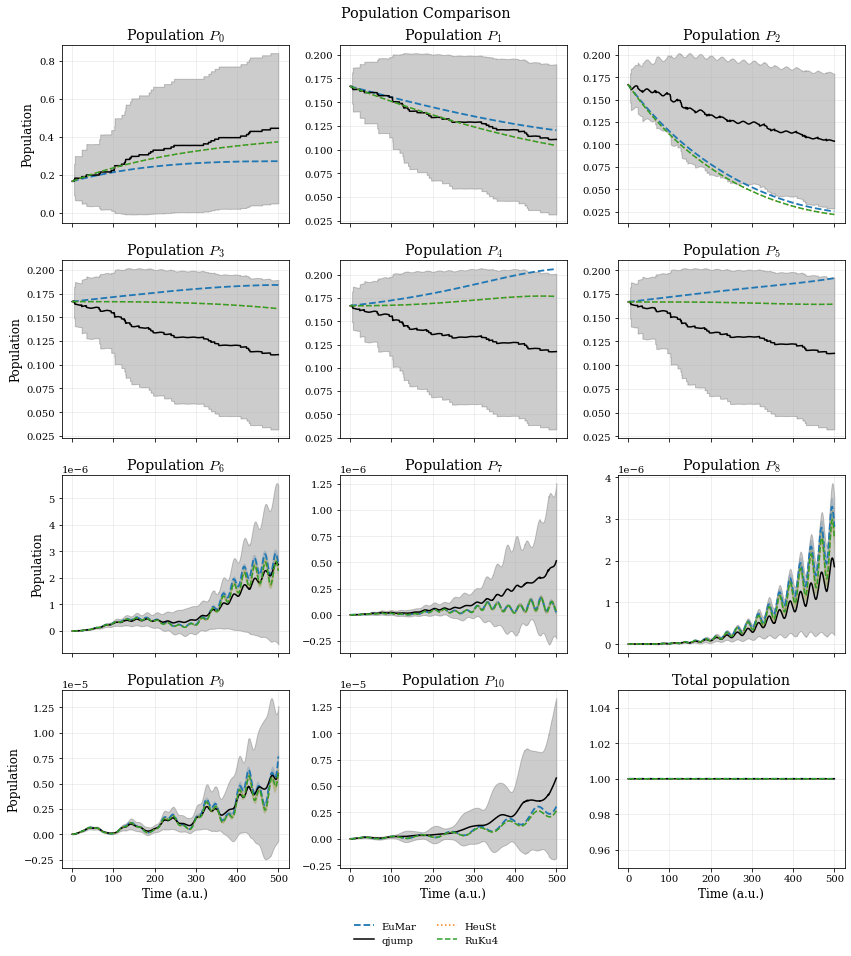

In [39]:
nrows, ncols = 4, 3
n_panels = nrows * ncols
n_state_panels = n_panels - 1  # Keep the last panel for total population.
n_states = min(pop_EuMar.shape[1], pop_qjump.shape[1], n_state_panels)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 14), sharex=True)
axes = axes.ravel()

# Panels 0..10: state-resolved populations.
for i in range(n_states):
    ax = axes[i]
    ax.plot(t_EuMar, pop_EuMar[:, i], lw=1.8, ls="--", label="EuMar")
    ax.fill_between(t_EuMar, pop_EuMar[:, i] - pop_std_EuMar[:, i], pop_EuMar[:, i] + pop_std_EuMar[:, i], alpha=0.2)
    ax.plot(t_qjump, pop_qjump[:, i], lw=1.5, label="qjump", color="black")
    ax.fill_between(t_qjump, pop_qjump[:, i] - pop_std_qjump[:, i], pop_qjump[:, i] + pop_std_qjump[:, i], alpha=0.2, color="black") 
    ax.plot(t_HeuSt, pop_HeuSt[:, i], lw=1.5, ls=":", label="HeuSt")
    ax.fill_between(t_HeuSt, pop_HeuSt[:, i] - pop_std_HeuSt[:, i], pop_HeuSt[:, i] + pop_std_HeuSt[:, i], alpha=0.2)
    ax.plot(t_RuKu4, pop_RuKu4[:, i], lw=1.5, ls="--", label="RuKu4")
    ax.fill_between(t_RuKu4, pop_RuKu4[:, i] - pop_std_RuKu4[:, i], pop_RuKu4[:, i] + pop_std_RuKu4[:, i], alpha=0.2)
    ax.set_title(rf"Population $P_{{{i}}}$")
    ax.grid(alpha=0.25)

# Last panel: total population.
ax_total = axes[-1]
ax_total.plot(t_EuMar, pop_EuMar.sum(axis=1), lw=1.8, ls="--", label="EuMar")
ax_total.plot(t_qjump, pop_qjump.sum(axis=1), lw=1.5, label="qjump", color="black")
ax_total.plot(t_HeuSt, pop_HeuSt.sum(axis=1), lw=1.5, ls=":", label="HeuSt")
ax_total.plot(t_RuKu4, pop_RuKu4.sum(axis=1), lw=1.5, ls="--", label="RuKu4")
ax_total.set_ylim(0.95, 1.05)
ax_total.set_title("Total population")
ax_total.grid(alpha=0.25)

# Hide any unused state panels (if fewer than 11 states are available).
for i in range(n_states, n_state_panels):
    axes[i].axis("off")

for ax in axes[(nrows - 1) * ncols:]:
    ax.set_xlabel("Time (a.u.)")

for row in range(nrows):
    axes[row * ncols].set_ylabel("Population")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.01))
fig.suptitle("Population Comparison", y=0.95)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()